### Building chatbot with multiple tools using langgraph

### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions 

In [1]:
import arxiv
import wikipedia
import os

In [2]:
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:
from langchain_groq import ChatGroq

In [4]:
from langchain_core.messages import AIMessage, HumanMessage

In [5]:
llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [6]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [7]:
arxiv.arxiv._DEFAULT_TIME = 10

# Patch the base URL
arxiv.arxiv.Client.query_url_format = \
    "https://export.arxiv.org/api/query?{}"

In [8]:
search = arxiv.Search(
    query="Attention is all you need",
    max_results=5,
    sort_by=arxiv.SortCriterion.Relevance
)

In [9]:
client = arxiv.Client()
# Fetch results
results = client.results(search)

In [10]:
for paper in results:
    print("Title:", paper.title)
    print("Authors:", [author.name for author in paper.authors])
    print("Published:", paper.published)
    print("Summary:", paper.summary[:500])
    print("-" * 80)

Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: ['Luke Melas-Kyriazi']
Published: 2021-05-06 14:42:39+00:00
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a
--------------------------------------------------------------------------------
Title: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
Authors: ['Anton Alyakin']
Published: 2025-12-03 17:36:45+00:00
Summary: The 2017 paper ''Attention Is All You Need'' introduced the Transform

In [11]:
import wikipediaapi

wiki = wikipediaapi.Wikipedia(
    user_agent='MyAIResearchBot/1.0',
    language='en'
)

page = wiki.page("Attention Is All You Need")

print("Title:", page.title)
print("Summary:")
print(page.summary[:500])

Title: Attention Is All You Need
Summary:
"Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence, including large language models. At the time, the focus of the research was on improving Seq2seq te


In [24]:
def wikipedia_search(query:str)->str:
    """
    Search Wikipedia for general knowledge.

    Args:
        query: Topic to search.
    """
    wiki = wikipediaapi.Wikipedia(
    user_agent='MyAIResearchBot/1.0',
    language='en')
    page = wiki.page(query)
    if page.exists():
        return f"Title: {page.title}\nSummary: {page.summary[:500]}"
    else:
        return "No Wikipedia page found for the query."

In [25]:
def arxiv_search(query:str)->str:
    """
    Search arXiv research papers.

    Args:
        query: AI/ML/scientific research query.
    """
    arxiv.arxiv._DEFAULT_TIME = 10
    # Patch the base URL
    arxiv.arxiv.Client.query_url_format = \
    "https://export.arxiv.org/api/query?{}"
    search = arxiv.Search(
    query=query,
    max_results=5,
    sort_by=arxiv.SortCriterion.Relevance)
    client = arxiv.Client()
    results = client.results(search)
    return "\n\n".join([f"Title: {paper.title}\nAuthors: {[author.name for author in paper.authors]}\nPublished: {paper.published}\nSummary: {paper.summary[:500]}" for paper in results])

In [26]:
arxiv_search("Attention is all you need")

'Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: [\'Luke Melas-Kyriazi\']\nPublished: 2021-05-06 14:42:39+00:00\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a\n\nTitle: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme\nAuthors: [\'Anton Alyakin\']\nPublished: 2025-12-03 17:36:45+00:00\nSummary: The 2017 paper \'\'Attention Is All You Need\'\' introduced the Transformer architecture-and inadvertently spawned one of machine learni

In [27]:
tavily_search_tool.invoke("What is the latest research on attention mechanisms in deep learning?")

{'query': 'What is the latest research on attention mechanisms in deep learning?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.sciencedirect.com/science/article/abs/pii/S092523122100477X',
   'title': 'A review on the attention mechanism of deep learning - ScienceDirect',
   'content': 'Most of the attention mechanisms in deep learning are designed according to specific tasks so that most of them are focused attention. The',
   'score': 0.9999448,
   'raw_content': None},
  {'url': 'https://www.researchgate.net/publication/394999202_Attention_Mechanisms_in_Deep_Learning_A_Comprehensive_Survey_from_Foundations_to_Modern_Applications',
   'title': 'Attention Mechanisms in Deep Learning: A Comprehensive Survey ...',
   'content': 'This comprehensive survey traces the evolution of attention mechanisms from their origins in machine translation to their current status as',
   'score': 0.99990165,
   'raw_content': None},
  {'url': 'https://

In [28]:
def tavily_search(query:str)->str:
    """
    Search the web for recent news and current updates.
    
    Args:
      query (str): The search query.
    
    Returns:
      str: The search results."""
    return tavily_search_tool.invoke(query)

In [17]:
tavily_search("What is the latest research on attention mechanisms in deep learning?")

{'query': 'What is the latest research on attention mechanisms in deep learning?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.researchgate.net/publication/394999202_Attention_Mechanisms_in_Deep_Learning_A_Comprehensive_Survey_from_Foundations_to_Modern_Applications',
   'title': 'Attention Mechanisms in Deep Learning: A Comprehensive Survey ...',
   'content': 'This comprehensive survey traces the evolution of attention mechanisms from their origins in machine translation to their current status as',
   'score': 0.72559077,
   'raw_content': None},
  {'url': 'https://www.freecodecamp.org/news/what-are-attention-mechanisms-in-deep-learning',
   'title': 'What are Attention Mechanisms in Deep Learning? - freeCodeCamp',
   'content': 'Attention mechanism is a technique used in deep learning models that allows the model to selectively focus on specific areas of the input data',
   'score': 0.6793707,
   'raw_content': None},
  {'url': 'h

In [29]:
### Combining all the tools in the list
tools=[wikipedia_search,arxiv_search,tavily_search]

In [30]:
llm_with_tools=llm.bind_tools(tools,tool_choice="any")

In [31]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News?")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0apmke9my', 'function': {'arguments': '{"query":"Recent AI News"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 822, 'total_tokens': 855, 'completion_time': 0.07458193, 'completion_tokens_details': None, 'prompt_time': 0.033733504, 'prompt_tokens_details': None, 'queue_time': 0.291287954, 'total_time': 0.108315434}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e58a9-3adf-7cd3-84a6-a314802eb642-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Recent AI News'}, 'id': '0apmke9my', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 822, 'output_tokens': 33, 'total_tokens': 855})

### Creating the chatbot

In [33]:
## State schema
from typing import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

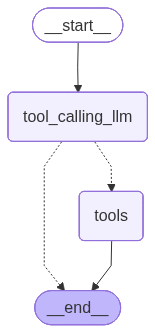

In [40]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#node definitions
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

def decide_next_node(state: State):
    
    last_message = state["messages"][-1]

    # Check whether the AI generated tool calls
    if last_message.tool_calls:
        return "tools"

    return END

#Build graph:

#Add edges:
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#Adding edges:
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    #If the latest message (result) from assistant is not a tool call -> END
    decide_next_node,
    {
        "tools":"tools",
        END:END
    }
)

# builder.add_conditional_edges(
#     "tool_calling_llm",
#     #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
#     #If the latest message (result) from assistant is not a tool call -> END
#     tools_condition
# )
#builder.add_edge("tools",END)

# builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tools", END)

graph=builder.compile()

#View
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
messages=graph.invoke({"messages":HumanMessage(content="What is attention is all you need")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is attention is all you need
================================== Ai Message ==================================
Tool Calls:
  wikipedia_search (8qc62p8qz)
 Call ID: 8qc62p8qz
  Args:
    query: attention is all you need
================================= Tool Message =================================
Name: wikipedia_search

Title: Attention Is All You Need
Summary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence, including large language models. At the time, the focus of the research was on improving Seq2seq te


In [42]:
messages=graph.invoke({"messages":HumanMessage(content="What is the latest research on attention mechanisms in deep learning?")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the latest research on attention mechanisms in deep learning?
================================== Ai Message ==================================
Tool Calls:
  arxiv_search (1w70tgax8)
 Call ID: 1w70tgax8
  Args:
    query: attention mechanisms in deep learning latest research
================================= Tool Message =================================
Name: arxiv_search

Title: The Modern Mathematics of Deep Learning
Authors: ['Julius Berner', 'Philipp Grohs', 'Gitta Kutyniok', 'Philipp Petersen']
Published: 2021-05-09 21:30:42+00:00
Summary: We describe the new field of mathematical analysis of deep learning. This field emerged around a list of research questions that were not answered within the classical framework of learning theory. These questions concern: the outstanding generalization power of overparametrized neural networks, the role of depth in deep architectures, the apparent absence 

In [43]:
messages=graph.invoke({"messages":HumanMessage(content="What is the current aqi of delhi?")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the current aqi of delhi?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (tsnhdp5fm)
 Call ID: tsnhdp5fm
  Args:
    query: Delhi current AQI
================================= Tool Message =================================
Name: tavily_search

{"query": "Delhi current AQI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.aqi.in/us/dashboard/india/delhi", "title": "Delhi Air Quality Index (AQI) | Air Pollution", "content": "Current Delhi Air Quality Index (AQI) is 95 Moderate level with real-time air pollution PM2.5 (32µg/m³), PM10 (46µg/m³), Temperature (37.2°C) in Delhi.", "score": 0.94536424, "raw_content": null}, {"url": "https://en.wikipedia.org/wiki/Air_pollution_in_Delhi", "title": "Air pollution in Delhi - Wikipedia", "content": "On November 18, 2024, Delhi recorded its worst air qualit